# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [1]:
# Get the datasets
!!/usr/bin/curl --output test.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/test_small.txt
!!/usr/bin/curl --output train.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/train.txt

['  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current',
 '                                 Dload  Upload   Total   Spent    Left  Speed',
 '',
 '  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0',
 '100 11645  100 11645    0     0  91949      0 --:--:-- --:--:-- --:--:-- 92420']

In [2]:
# Take a peek at the datasets
!head train.dat
!head test.dat

A1	A2	A3	A4	A5	A6	A7	A8	A9	A10	A11	A12	A13	
1	1	0	0	0	0	0	0	1	1	0	0	1	0
0	0	1	1	0	1	1	0	0	0	0	0	1	0
0	1	0	1	1	0	1	0	1	1	1	0	1	1
0	0	1	0	0	1	0	1	0	1	1	1	1	0
0	1	0	0	0	0	0	1	1	1	1	1	1	0
0	1	1	1	0	0	0	1	0	1	1	0	1	1
0	1	1	0	0	0	1	0	0	0	0	0	1	0
0	0	0	1	1	0	1	1	1	0	0	0	1	0
0	0	0	0	0	0	1	0	1	0	1	0	1	0
X1	X2	X3
1	1	1	1
0	0	1	1
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
1	1	1	1


### Build the Perceptron Model
You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [5]:
import math
import re

# Corpus reader: all columns but the last one are coordinates;
# the last column is the label
def read_data(file_name):
    with open(file_name, 'r') as f:
        data = []
        f.readline()  # discard header
        for line in f:
            if '\t' not in line:
                continue
            instance = list(map(int, line.strip().split('\t')))
            # Add a dummy input so that w0 becomes the bias
            instance = [-1] + instance
            data.append(instance)
    return data

def dot_product(weights, instance):
    # dot(weights, inputs); ignore last element because it's the label
    return sum(w * x for w, x in zip(weights, instance[:-1]))

def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

# Model output = sigmoid(dot_product(weights, instance))
def output(weights, instance):
    return sigmoid(dot_product(weights, instance))

# Predict label: 1 if >= 0.5 else 0
def predict(weights, instance):
    return 1 if output(weights, instance) >= 0.5 else 0

def get_accuracy(weights, instances):
    correct = sum(1 for inst in instances if predict(weights, inst) == inst[-1])
    return correct * 100 / len(instances)

def train_perceptron(instances, lr, epochs):
    # Initialize weights (including bias)
    weights = [0.0] * (len(instances[0]) - 1)

    for _ in range(epochs):
        for instance in instances:
            # Forward pass
            y_hat = output(weights, instance)

            # Error (target - prediction)
            error = instance[-1] - y_hat

            # Gradient descent update for logistic unit:
            # d/dw = error * sigmoid'(z) * x
            grad_factor = error * y_hat * (1 - y_hat)
            for i in range(len(weights)):
                weights[i] += lr * grad_factor * instance[i]

    return weights

## Run it

In [6]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
lr = 0.005
epochs = 5
weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)
print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4


## Questions

Answer the following questions. Include your implementation and the output for each question.

### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)
We do not use predict(weights, instance) during training because predict() returns a discrete class label (0 or 1) after applying a threshold at 0.5, whereas training requires the continuous output of the sigmoid function. The learning process relies on gradient-based updates, which depend on the derivative of the sigmoid function, given by ```\sigma(z)(1 - \sigma(z))```. This derivative is only meaningful when the output is a continuous probability value between 0 and 1. If we used predict(), the output would be limited to 0 or 1, removing the smooth gradient information needed to adjust the weights properly. Since a thresholded prediction is not differentiable, it cannot support gradient descent. Therefore, during training, we use the sigmoid output to compute meaningful errors and update the weights, while predict() is used only during evaluation to produce final class labels.


### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 
```
#tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 28.6
#tr:  40, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 28.6
#tr: 200, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 200, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs:   5, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  10, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  20, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  50, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr:  20, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr:  20, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr:  40, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr:  40, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr: 100, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr: 100, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr: 100, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 28.6
#tr: 200, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 200, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 200, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 200, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 200, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 300, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs:   5, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  10, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  20, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs:  50, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
#tr: 400, epochs: 100, learning rate: 0.050; Accuracy (test, 14 instances): 71.4
```

In [9]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")

tr_percent = [5, 10, 25, 50, 75, 100]   # percent of training dataset
num_epochs = [5, 10, 20, 50, 100]       # number of epochs
lr_array = [0.005, 0.01, 0.05]          # learning rate

results = []   # store (train_size, epochs, lr, accuracy)

for lr in lr_array:
    for tr_size in tr_percent:
        for epochs in num_epochs:
            size = round(len(instances_tr) * tr_size / 100)
            pre_instances = instances_tr[0:size]

            weights = train_perceptron(pre_instances, lr, epochs)
            accuracy = get_accuracy(weights, instances_te)

            # Store results for plotting
            results.append((len(pre_instances), epochs, lr, accuracy))

            print(f"#tr: {len(pre_instances):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
                  f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learn

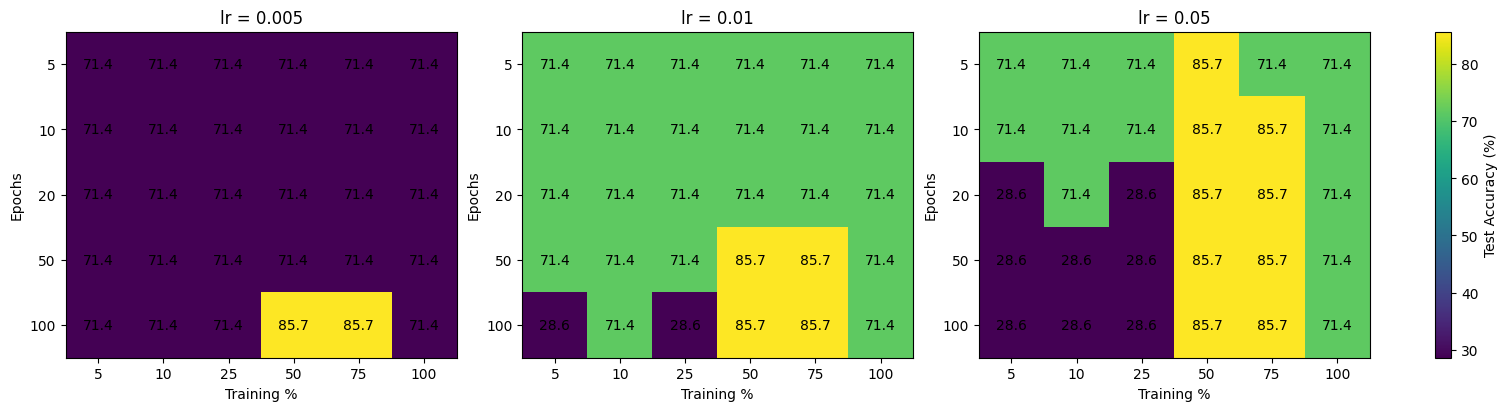

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- build dataframe ----
df = pd.DataFrame(results, columns=["train_size", "epochs", "lr", "accuracy"])

full_tr = len(instances_tr)
df["tr_percent"] = (df["train_size"] / full_tr * 100).round().astype(int)

wanted_percents = [5, 10, 25, 50, 75, 100]
df = df[df["tr_percent"].isin(wanted_percents)]

df["tr_percent"] = pd.Categorical(df["tr_percent"], categories=wanted_percents, ordered=True)
df["epochs"] = pd.Categorical(df["epochs"], categories=[5, 10, 20, 50, 100], ordered=True)

# ---- horizontal dashboard (all lrs in one row) ----
unique_lrs = sorted(df["lr"].unique())
n = len(unique_lrs)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4), constrained_layout=True)

# If only one lr, axes won't be iterable
if n == 1:
    axes = [axes]

for ax, lr in zip(axes, unique_lrs):
    sub = df[df["lr"] == lr].copy()

    pivot = sub.pivot_table(
        index="epochs",
        columns="tr_percent",
        values="accuracy",
        aggfunc="mean",
        observed=False
    ).sort_index()

    Z = pivot.to_numpy(dtype=float)

    im = ax.imshow(Z, aspect="auto")
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(i) for i in pivot.index])

    ax.set_xlabel("Training %")
    ax.set_ylabel("Epochs")
    ax.set_title(f"lr = {lr}")

    # annotate values
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            if not pd.isna(Z[i, j]):
                ax.text(j, i, f"{Z[i, j]:.1f}", ha="center", va="center")

# single shared colorbar
fig.colorbar(im, ax=axes, label="Test Accuracy (%)")

plt.show()

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
```
From the grid search results across all combinations of training size, epochs, and learning rate, we observe that test accuracy does not increase monotonically with more training data or more epochs. In many cases, the model achieves a baseline accuracy of 71.4%, which likely corresponds to correctly classifying 10 out of 14 test instances. However, certain combinations (e.g., training sizes of 200–300 with appropriate epochs and learning rates) achieve a higher accuracy of 85.7% (12 out of 14 correct). This indicates that performance depends strongly on the interaction between hyperparameters rather than any single parameter alone.

- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?

No, it is not necessary to use the full training dataset to obtain the highest test accuracy. The results show that training with 200 or 300 instances sometimes achieves 85.7% accuracy, while using 400 instances often drops back to 71.4%. This suggests that simply adding more data does not automatically improve generalization. The additional data may introduce noise or shift the decision boundary slightly in a way that reduces test performance. Therefore, more training data does not always guarantee better accuracy.

- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?

#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0

The second run performs worse, even though it uses more training data, because the learning rate is much lower (0.005 vs 0.050). A smaller learning rate leads to slower weight updates, which may prevent the model from reaching a good decision boundary within 20 epochs. In contrast, the higher learning rate (0.050) allows faster convergence. This demonstrates that hyperparameters interact: increasing training size alone does not compensate for suboptimal learning rate settings. Model performance depends on both optimization dynamics and dataset size.


- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?

Yes. The results already show 85.7% accuracy for several combinations (for example, training sizes 200–300 with appropriate epochs and learning rates). This confirms that performance above 80% is achievable without changing the model architecture. It is possible that tuning additional hyperparameters—such as trying intermediate learning rates (e.g., 0.02 or 0.03), shuffling training data, increasing epochs moderately, or using better initialization—could further stabilize or slightly improve performance. However, given the small test set (14 instances), improvements may be limited and somewhat sensitive to small changes.
  
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?

No, training for more epochs does not always improve performance. In several cases, increasing epochs from 20 to 100 either had no effect or even reduced accuracy (e.g., some combinations dropped from 71.4% to 28.6% when using higher learning rates). This suggests that with larger learning rates, too many epochs can cause unstable updates or overshooting of the optimal solution. In other cases, more epochs helped (e.g., 200 training samples with lr=0.005 improved at 100 epochs). Therefore, more epochs can help only when paired with an appropriate learning rate; otherwise, they may lead to diminishing returns or instability.

```
